# Yelp: EDA, Visualization, and GPU TensorFlow
Quick end-to-end exploration and rating prediction on sampled Yelp data.

In [1]:
from __future__ import annotations

from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 40)

DATA_DIR = Path(os.environ["PLG_GROUPS_STORAGE"]) / "plgglscclass" / "yelp-dataset"
BUSINESS_PATH = DATA_DIR / "yelp_academic_dataset_business.json"
REVIEW_PATH = DATA_DIR / "yelp_academic_dataset_review.json"

SEED = 42
BUSINESS_N = 120_000
REVIEW_N = 300_000

print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass
print("GPU devices:", gpus if gpus else "none detected")
print("Data dir:", DATA_DIR)

2026-03-19 20:18:18.499564: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-19 20:18:18.551199: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Data dir: /net/pr2/projects/plgrid/plgglscclass/yelp-dataset


In [2]:
business_cols = ["business_id", "city", "state", "stars", "review_count", "is_open", "categories"]
review_cols = ["business_id", "stars", "useful", "funny", "cool", "text"]

business = pd.read_json(BUSINESS_PATH, lines=True, nrows=BUSINESS_N)[business_cols]
reviews = pd.read_json(REVIEW_PATH, lines=True, nrows=REVIEW_N)[review_cols]

reviews["text_len"] = reviews["text"].str.len()
df = reviews.merge(business, on="business_id", how="inner", suffixes=("_review", "_biz"))
df = df.dropna(subset=["stars_review", "stars_biz", "city"]).copy()

print("business rows:", len(business), "review rows:", len(reviews), "merged rows:", len(df))
df.head(3)

business rows: 120000 review rows: 300000 merged rows: 300000


,business_id,stars_review,useful,funny,cool,text,text_len,city,state,stars_biz,review_count,is_open,categories
0,XQfwVwDr-v0ZS3_CbbE5Xw,3,0,0,0,"If you decide to eat here, just be aware it is...",513,North Wales,PA,3.0,169,1,"Restaurants, Breakfast & Brunch, Food, Juice B..."
1,7ATYjTIgM3jUlt4UM3IypQ,5,1,0,1,I've taken a lot of spin classes over the year...,829,Philadelphia,PA,5.0,144,0,"Active Life, Cycling Classes, Trainers, Gyms, ..."
2,YjUWPpI6HXG530lwP-fb2A,3,0,0,0,Family diner. Had the buffet. Eclectic assortm...,339,Tucson,AZ,3.5,47,1,"Restaurants, Breakfast & Brunch"


## Quick Exploration
Shape, null checks, and high-level distributions.

In [3]:
display(df[["stars_review", "stars_biz", "review_count", "is_open", "text_len"]].describe().T)

city_counts = df["city"].value_counts().head(10)
print("Top cities:\n", city_counts.to_string())

cat_counts = (
    df["categories"]
    .fillna("")
    .str.split(",")
    .explode()
    .str.strip()
    .replace("", np.nan)
    .dropna()
    .value_counts()
    .head(10)
)
print("\nTop categories:\n", cat_counts.to_string())

,count,mean,std,min,25%,50%,75%,max
stars_review,300000.0,3.835867,1.361942,1.0,3.0,4.0,5.0,5.0
stars_biz,300000.0,3.768218,0.679296,1.0,3.5,4.0,4.0,5.0
review_count,300000.0,386.602843,620.478799,5.0,59.0,167.0,430.0,4554.0
is_open,300000.0,0.768293,0.421923,0.0,1.0,1.0,1.0,1.0
text_len,300000.0,551.803377,505.511158,1.0,226.0,396.0,699.0,5000.0


Top cities:
 city
Philadelphia     51176
New Orleans      34737
Nashville        19524
Tampa            16863
Tucson           15363
Indianapolis     15284
Reno             13967
Saint Louis      13950
Santa Barbara    11064
Edmonton          4962

Top categories:
 categories
Restaurants                  215621
Food                          88291
Nightlife                     70028
Bars                          65643
American (New)                49556
American (Traditional)        42681
Breakfast & Brunch            42159
Event Planning & Services     29857
Sandwiches                    29775
Seafood                       24141


## Visualization
A few compact plots for ratings and geography.

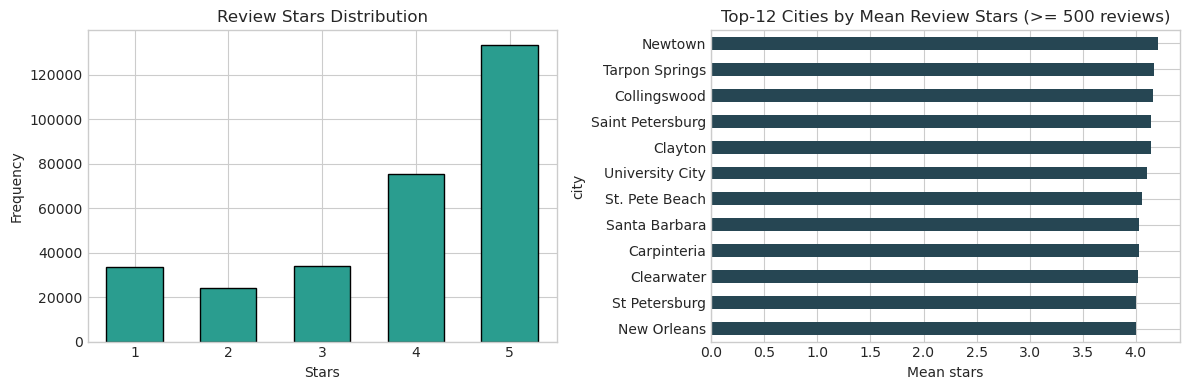

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

star_counts = df["stars_review"].value_counts().sort_index()
ax[0].bar(star_counts.index, star_counts.values, color="#2a9d8f", edgecolor="black", width=0.6)
ax[0].set_title("Review Stars Distribution")
ax[0].set_xlabel("Stars")
ax[0].set_ylabel("Frequency")
ax[0].set_xticks([1, 2, 3, 4, 5])
ax[0].set_xlim(0.5, 5.5)

min_city_reviews = 500
city_stats = (
    df.groupby("city", as_index=False)["stars_review"]
    .agg(mean_stars="mean", n_reviews="count")
    .query("n_reviews >= @min_city_reviews")
)

(
    city_stats
    .sort_values("mean_stars", ascending=False)
    .head(12)
    .sort_values("mean_stars")
    .plot(kind="barh", x="city", y="mean_stars", ax=ax[1], color="#264653", legend=False)
)
ax[1].set_title(f"Top-12 Cities by Mean Review Stars (>= {min_city_reviews} reviews)")
ax[1].set_xlabel("Mean stars")

plt.tight_layout()
plt.show()

## ML (GPU TensorFlow)
Binary target: whether a review is high-rated ($\geq 4$ stars).

In [5]:
feature_cols = [
    "useful", "funny", "cool", "text_len",
    "stars_biz", "review_count", "is_open",
]

ml_df = df[feature_cols + ["stars_review"]].dropna().copy()
ml_df["target"] = (ml_df["stars_review"] >= 4).astype("int32")

X = ml_df[feature_cols].to_numpy(dtype="float32")
y = ml_df["target"].to_numpy(dtype="float32")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype("float32")
X_test = scaler.transform(X_test).astype("float32")

print("Train/Test:", X_train.shape, X_test.shape, "Positive rate:", y.mean().round(3))

Train/Test: (240000, 7) (60000, 7) Positive rate: 0.695


In [6]:
device_name = "/GPU:0" if gpus else "/CPU:0"
print("Training device:", device_name)

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc", mode="max", factor=0.5, patience=4, min_lr=1e-5, verbose=1
    ),
]

with tf.device(device_name):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.30),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.20),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(3e-4),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
        ],
    )

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=4096,
        callbacks=callbacks,
        verbose=1,
    )

loss, accuracy, auc, pr_auc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss={loss:.4f} | acc={accuracy:.4f} | auc={auc:.4f} | pr_auc={pr_auc:.4f}")

Training device: /GPU:0


I0000 00:00:1773947909.121296  583954 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 29147 MB memory:  -> device: 0, name: Tesla V100-SXM2-32GB, pci bus id: 0000:2d:00.0, compute capability: 7.0


Epoch 1/100


2026-03-19 20:18:31.893043: I external/local_xla/xla/service/service.cc:163] XLA service 0x1499480259f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-19 20:18:31.893061: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Tesla V100-SXM2-32GB, Compute Capability 7.0
2026-03-19 20:18:31.941040: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-19 20:18:32.205433: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700


39/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6831 - auc: 0.6519 - loss: 0.6249 - pr_auc: 0.7890

I0000 00:00:1773947914.319151  583993 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 128ms/step - accuracy: 0.7205 - auc: 0.7148 - loss: 0.5725 - pr_auc: 0.8353 - val_accuracy: 0.7327 - val_auc: 0.7501 - val_loss: 0.6008 - val_pr_auc: 0.8600 - learning_rate: 3.0000e-04
Epoch 2/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7418 - auc: 0.7521 - loss: 0.5314 - pr_auc: 0.8609 - val_accuracy: 0.7255 - val_auc: 0.7500 - val_loss: 0.5785 - val_pr_auc: 0.8628 - learning_rate: 3.0000e-04
Epoch 3/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7453 - auc: 0.7581 - loss: 0.5239 - pr_auc: 0.8655 - val_accuracy: 0.7271 - val_auc: 0.7566 - val_loss: 0.5611 - val_pr_auc: 0.8674 - learning_rate: 3.0000e-04
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7474 - auc: 0.7619 - loss: 0.5193 - pr_auc: 0.8687 - val_accuracy: 0.7356 - val_auc: 0.7661 - val_loss: 0.5505 - val_pr_auc: 0.8722 - learning_rate: 3.0000e-04
Epoch 5/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7490 - auc: 0.7645 - loss: 0.5169 - pr_auc: 

Best epoch=100 | best_val_auc=0.7809 | best_val_acc=0.7585
Test loss=0.4998 | acc=0.7591 | auc=0.7814 | pr_auc=0.8823


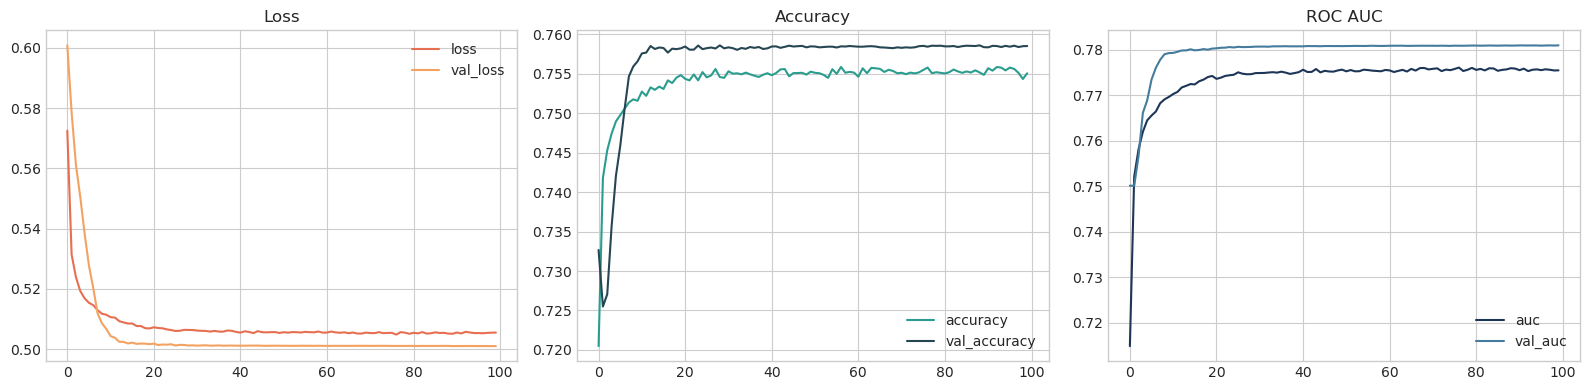

In [7]:
hist = pd.DataFrame(history.history)
best_epoch = int(hist["val_auc"].idxmax()) + 1
best_val_auc = float(hist["val_auc"].max())
best_val_acc = float(hist.loc[best_epoch - 1, "val_accuracy"])

loss, accuracy, auc, pr_auc = model.evaluate(X_test, y_test, verbose=0)
print(
    f"Best epoch={best_epoch} | best_val_auc={best_val_auc:.4f} | "
    f"best_val_acc={best_val_acc:.4f}"
)
print(f"Test loss={loss:.4f} | acc={accuracy:.4f} | auc={auc:.4f} | pr_auc={pr_auc:.4f}")

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
hist[["loss", "val_loss"]].plot(ax=ax[0], color=["#e76f51", "#f4a261"])
ax[0].set_title("Loss")

hist[["accuracy", "val_accuracy"]].plot(ax=ax[1], color=["#2a9d8f", "#264653"])
ax[1].set_title("Accuracy")

hist[["auc", "val_auc"]].plot(ax=ax[2], color=["#1d3557", "#457b9d"])
ax[2].set_title("ROC AUC")

plt.tight_layout()
plt.show()